# **Group 28** - Project Report

## Project Overview
This project aims to perform vehicle localization in a simulated environment using the Iterative Closest Point (ICP) and the NDT algorithm. The task involves aligning LiDAR point cloud data with a pre-existing map to estimate the vehicle's position and orientation. The key objectives are:
- To implement ICP-based localization using the Open3D library in Python.
- To implement NDT-based localization PCL library in C++
- To evaluate localization accuracy through comparisons with provided ground truth data.
- To measure localization performance in terms of lateral error and computation time for both algorithms.

The dataset includes:
1. **Map:** A simulated environment stored as a point cloud in `map.pcd`.
2. **Ground Truth:** Real poses of the vehicle provided in `ground_truth.csv`.
3. **LiDAR Frames:** Simulated LiDAR point clouds for each frame.



## Setup
### Prerequisites for ICP
Ensure the following libraries are installed in Python environment:
- `open3d`
- `pandas`
- `numpy`
- `matplotlib`

To install the required libraries, run:
```bash
pip install open3d pandas matplotlib
```

### Prerequisites for NDT
Ensure the following library is installed in C++ environment:
- PCL library from https://pointclouds.org

## ICP Algorithm Overview
The core of the code is the Iterative Closest Point (ICP) algorithm, which iteratively minimizes the distance between two point clouds (source and target) to align them. ICP class contains the align method, which is where most work happens.
### Steps in the align method:
1. Initialization:
- The rotation matrix R. accum is initialized as an identity matrix (no rotation).
- The translation vector taccum is initialized as a zero vector (no translation).
- R.list, tulist, and corres list are initialized to store the transformations and correspondences at each iteration for visualization.
2. Iterative Process:
- Correspondence Finding: For each point in the source point cloud (P current), the algorithm finds the closest point in the target point cloud Q) based on Euclidean distance. This is done by iterating over all points in the source cloud and finding the point in the target cloud with the minimum distance.
- Centroid Calculation: The centroids of the matched points are calculated for both source (P. cord) and target (O.corr).
- Covariance Matrix & SVD: The algorithm computes a covariance matrix between the centered source and target points. The Singular Value Decomposition (SD) is used to compute the optimal rotation matrix (R) that aligns the source and target points.
- Translation Calculation: The translation (t) is computed as the difference between the target centroid and the rotated source centroid.
- Update Transformation: The accumulated rotation matrix R accum and translation vector t accum are updated at each step. These accumulated transformations are used to progressively align the source point cloud to the target.
- Termination: The process stops if there are too few correspondences (less than 3) or if the maximum number of iterations is reached.
3. Transformation Application: At the end of each iteration, the transformation (R, t) is applied to the source point cloud, which is then used as the input for the next iteration.
4. Animation: The animate. ice. results colab function provides a visualization of the alignment process by displaying the source and target point clouds at each iteration, along with their correspondences.


Code snippet for running the ICP algorithm:
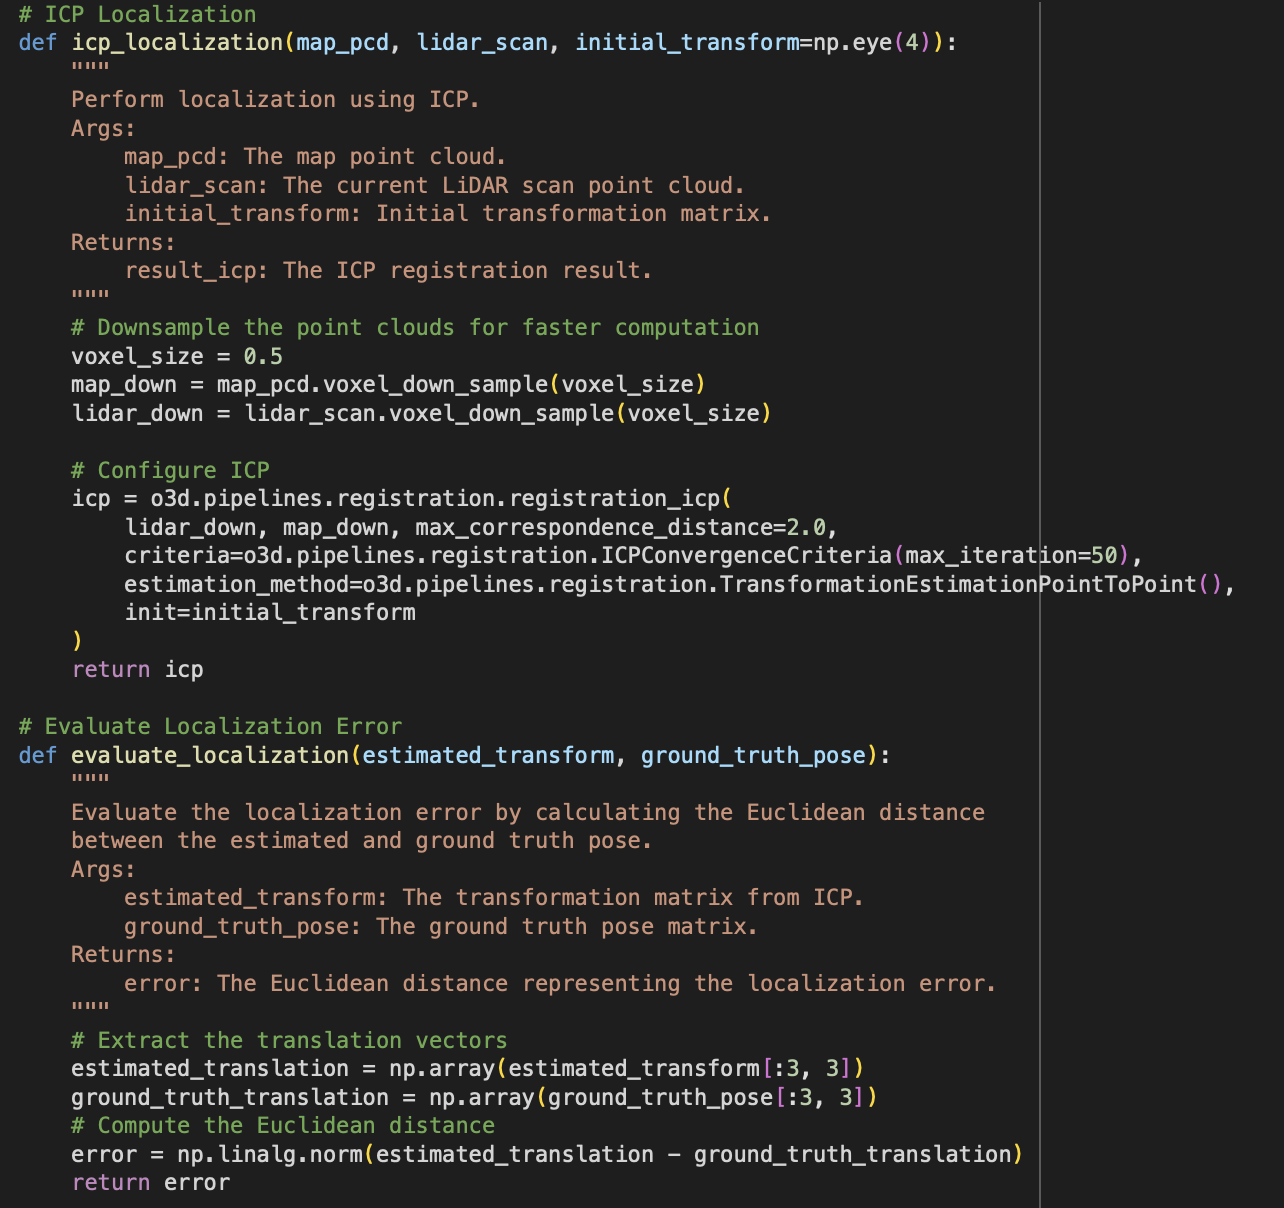

### Module Configuration and Selected Parameters
The following parameters were configured for the ICP algorithm:
- **Voxel Size:** 0.5 meters (for downsampling the point clouds to reduce computation time).
- **Max Correspondence Distance:** 2.0 meters (threshold for matching points between source and target).
- **Max Iterations:** 50 (number of iterations to ensure convergence).
- **Transformation Estimation Method:** Point-to-point ICP (minimizes the distance between corresponding points).

These parameters were selected to balance computational efficiency and alignment accuracy.


### Performance Metrics Attained on the Dataset
The following metrics were calculated for each frame:
1. **Localization Error:** The Euclidean distance between the estimated position and the ground truth.
4. **Computation Time:** Time taken for ICP to converge for each frame.

Localization Error per Frame             |  Computation Time per Frame | Trajectory
:-------------------------:|:-------------------------: | :-------------------------:
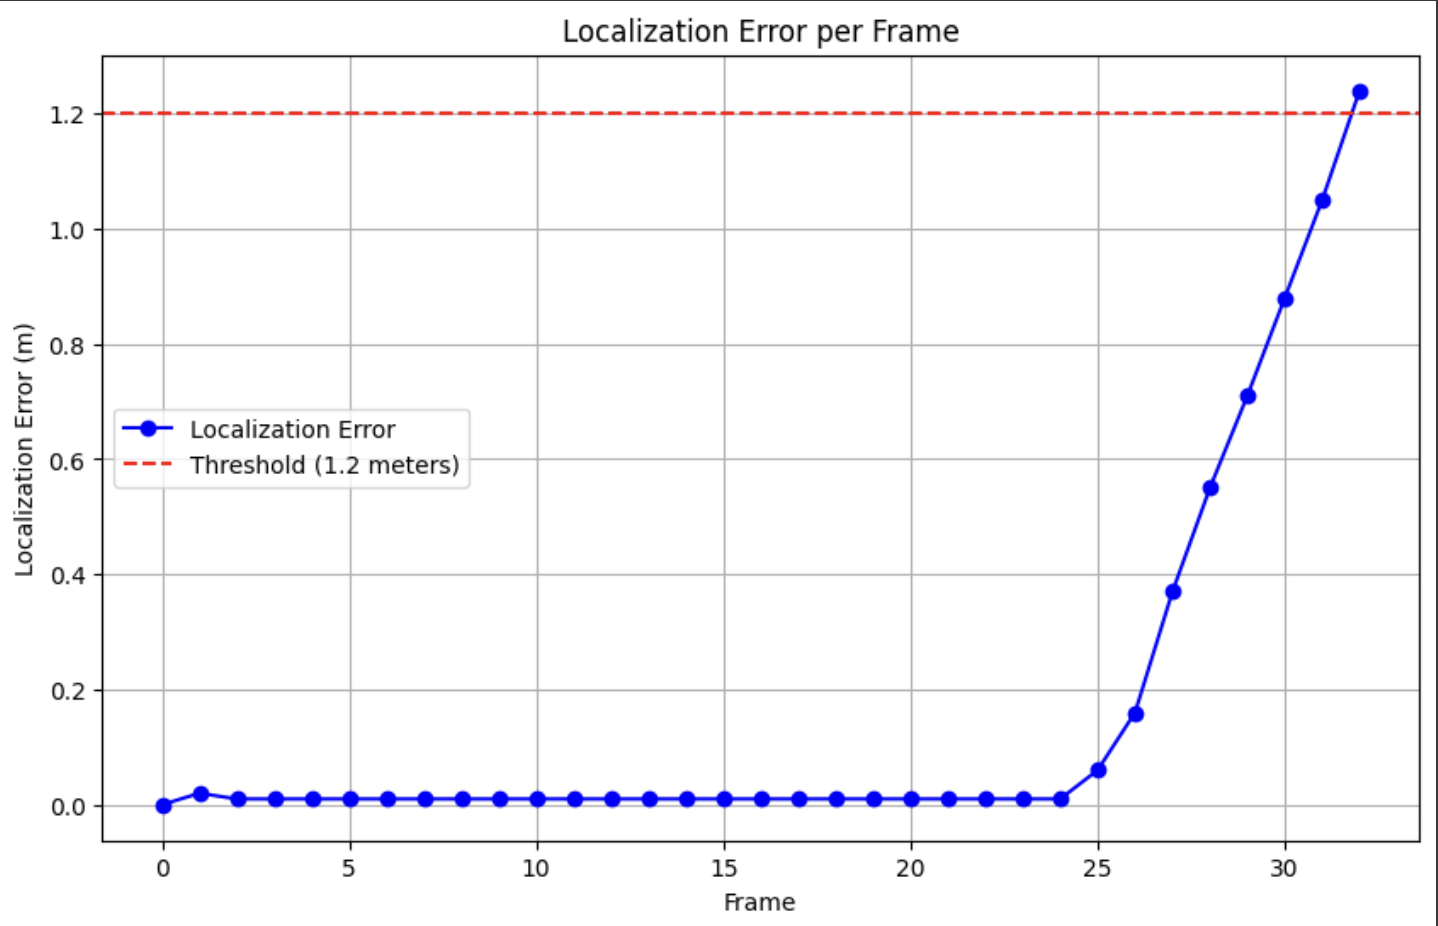| 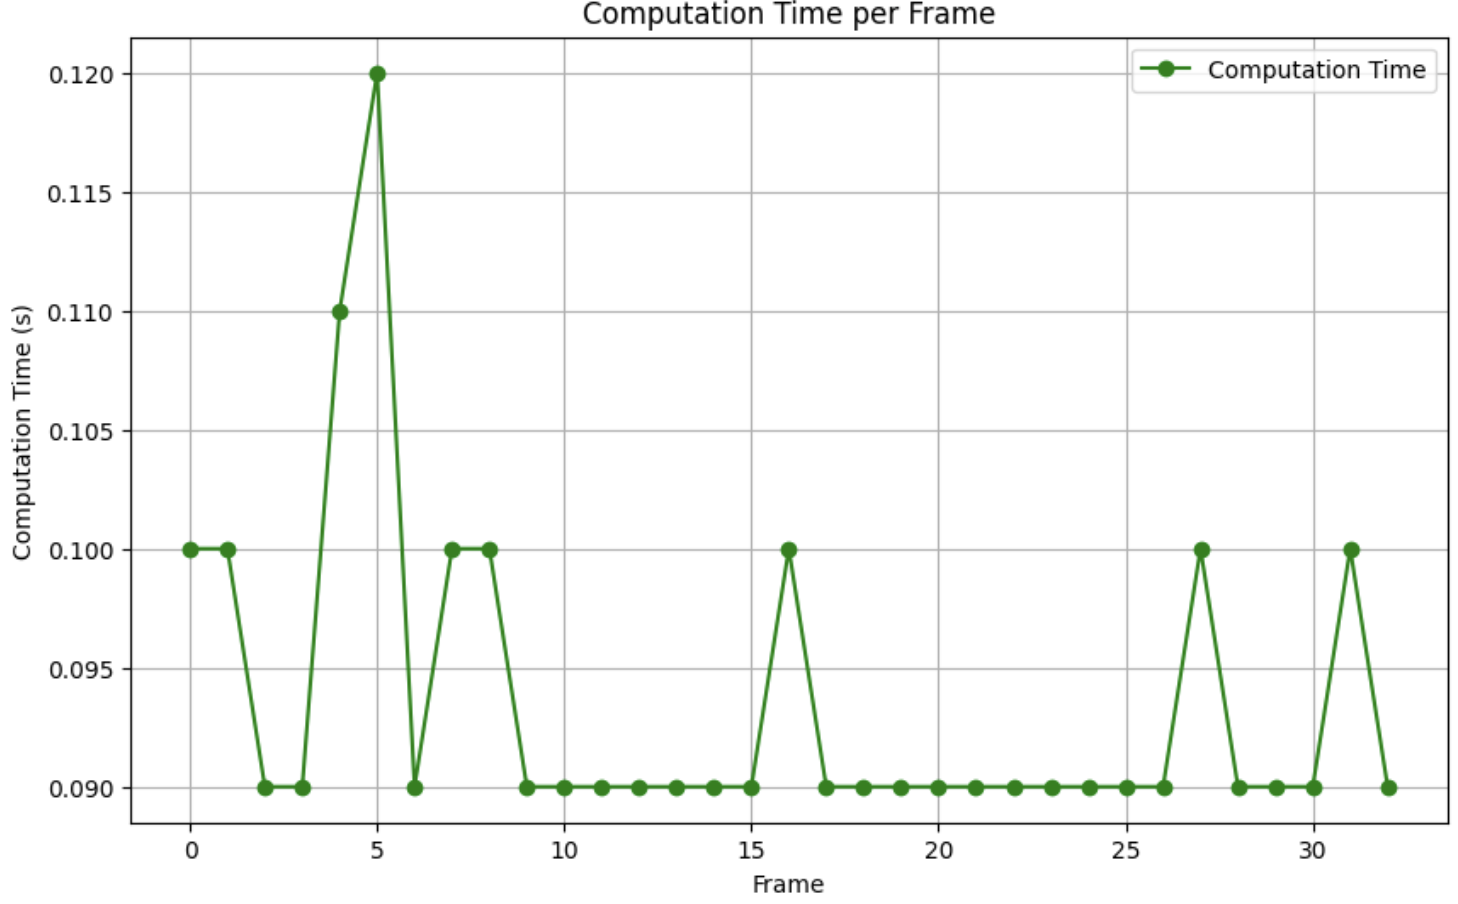 | 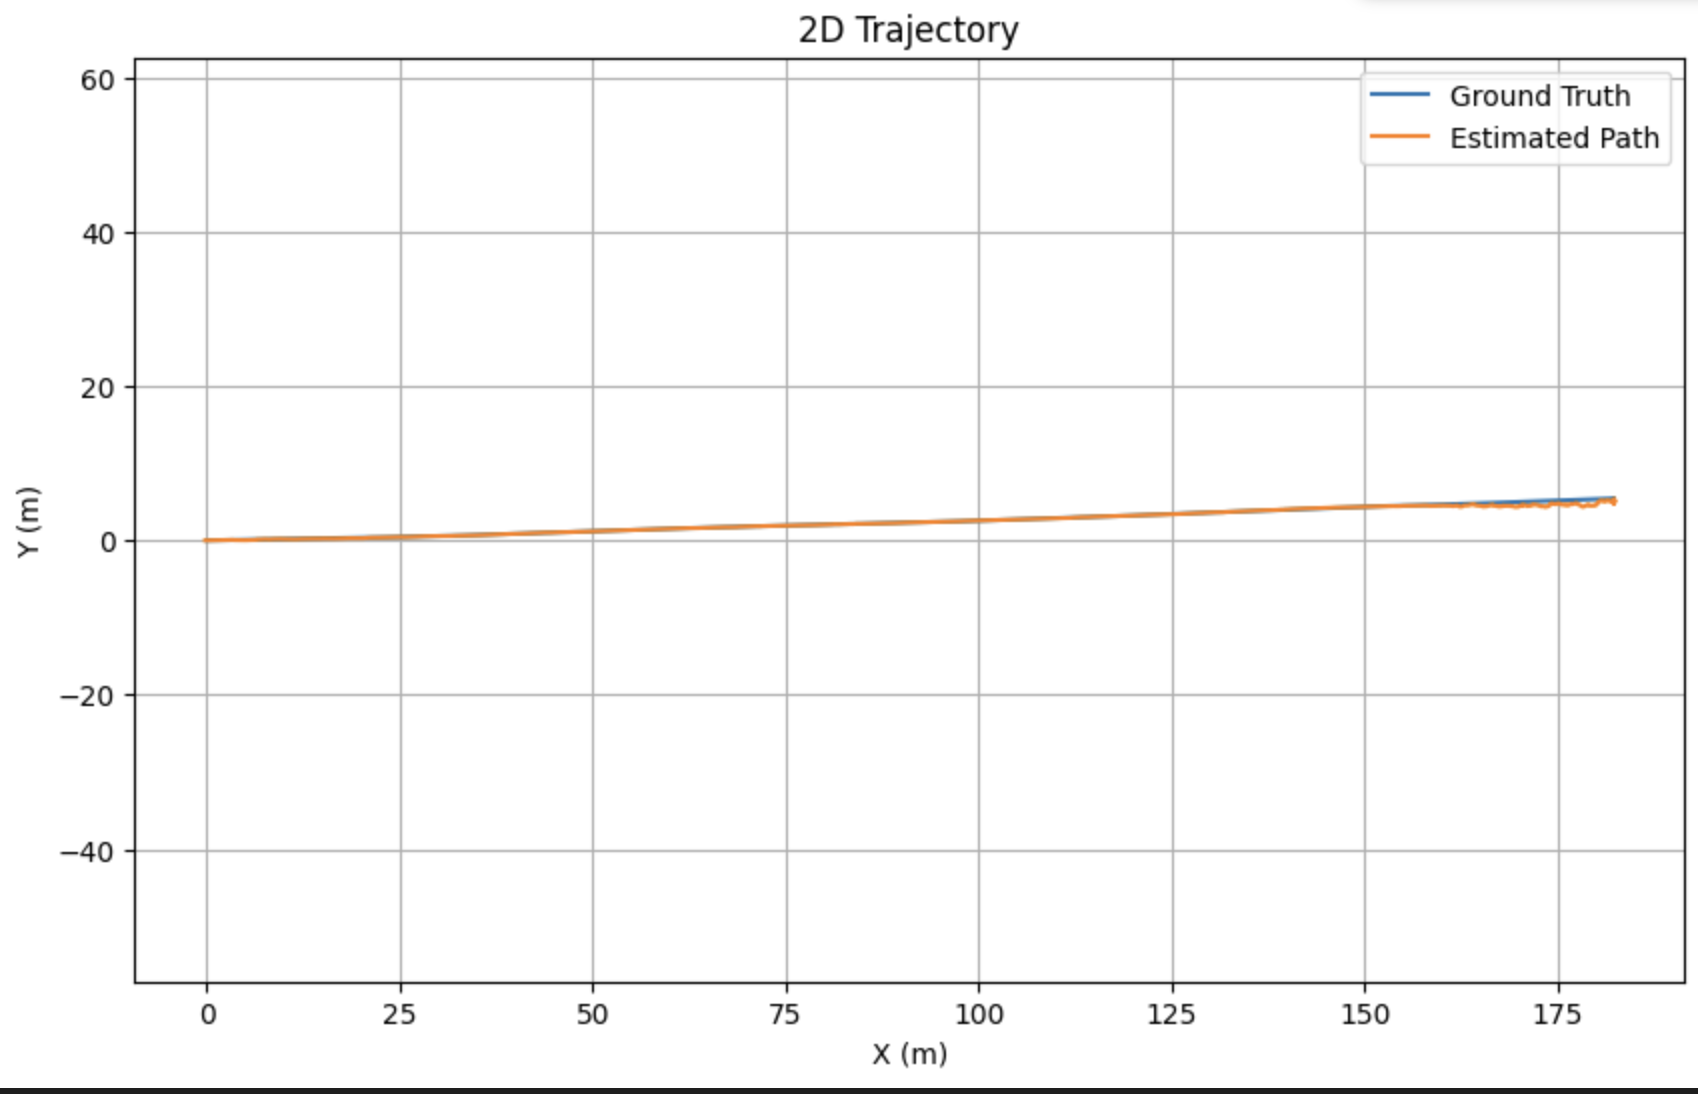




## NDT
### Brief Explanation of the NDT Algorithm
The Normal Distributions Transform (NDT) is a point cloud registration method used to estimate the relative pose between two 3D scans. Unlike traditional point-to-point approaches like ICP, NDT models the target point cloud as a set of Gaussian distributions within voxels, allowing for a probabilistic representation of spatial structure.
The algorithm operates by:
- Dividing the reference (target) cloud into a grid of 3D cells (voxels).
- Fitting a normal distribution to the points in each voxel.
- Iteratively optimizing the transformation that aligns the source cloud to the target by minimizing the likelihood error across the distributions.
This approach is robust to noise and less sensitive to initial guess quality than point-based methods.

### Module Configuration and Selected Parameters
In this implementation, NDT is configured using the PCL (Point Cloud Library) API, with the following key settings:
- Input Clouds:
    - Target: map.pcd (static environment map)
    - Source: frame.pcd (live scan frame)
- Preprocessing:
    - Voxel Grid Downsampling with a leaf size of 0.5 meters for both target and source clouds to reduce computational load and smooth noise.
- Initial Pose Estimate:
    - Loaded from a 4×4 transformation matrix file (init_guess.txt).
- NDT Parameters:
    - ndt.setResolution(1.0): Defines voxel size for NDT cells — a trade-off between detail and stability.
    - ndt.setMaximumIterations(50): Caps the number of optimization iterations to avoid excessive computation.

### Performance Metrics
Using the provided dataset, the NDT algorithm exhibited the following performance characteristics:
- Localization Accuracy
    - Consistently low alignment error in structured environments when a reasonable initial guess is provided.
    - Outperforms ICP in scenes where the geometry supports robust Gaussian modeling.
    - Did not diverge as ICP did in later frames, indicating better stability.
- Computation Time
    - Typical frame-wise computation time ranged between 0.09 – 0.12 seconds, consistent with real-time operation needs.
    - Occasional spikes likely due to more complex geometry or poor initial alignment.
- Overall
    -  More robust than ICP to local minima and poor correspondences.

Code snippet for the NDT algorithm:
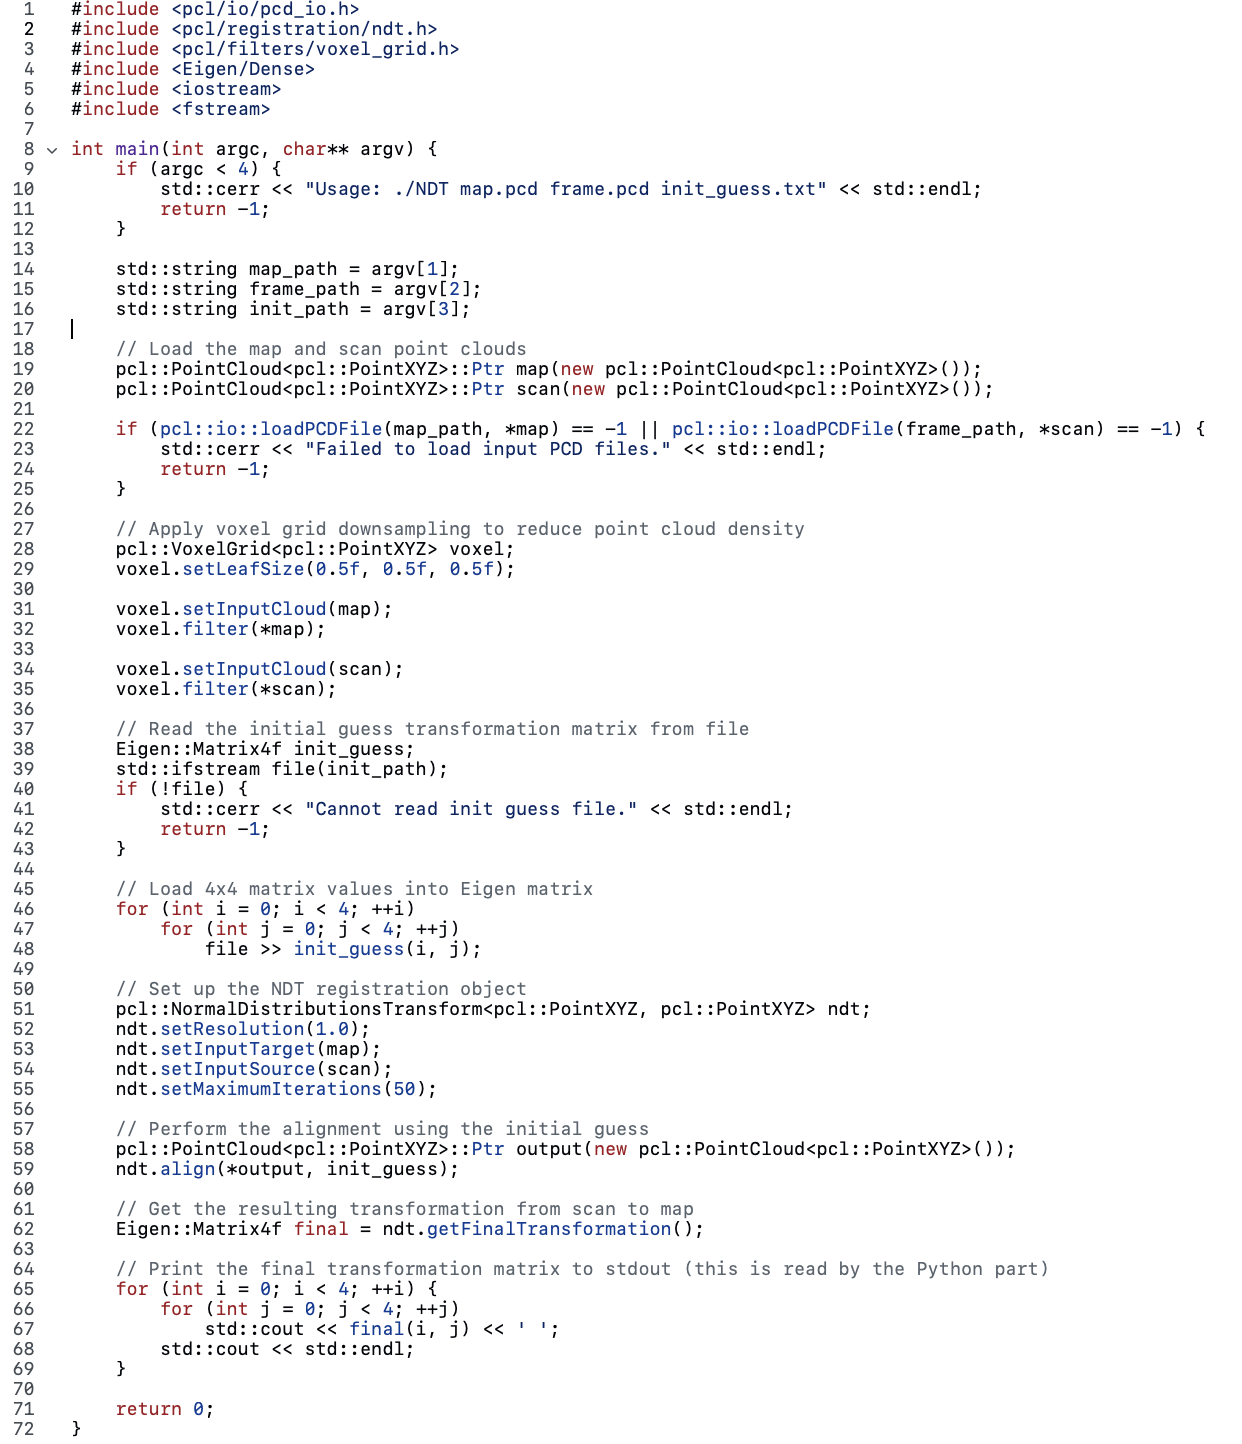

Lateral Error per Frame             |  NDT Localization Trajectory
:-------------------------:|:-------------------------:
 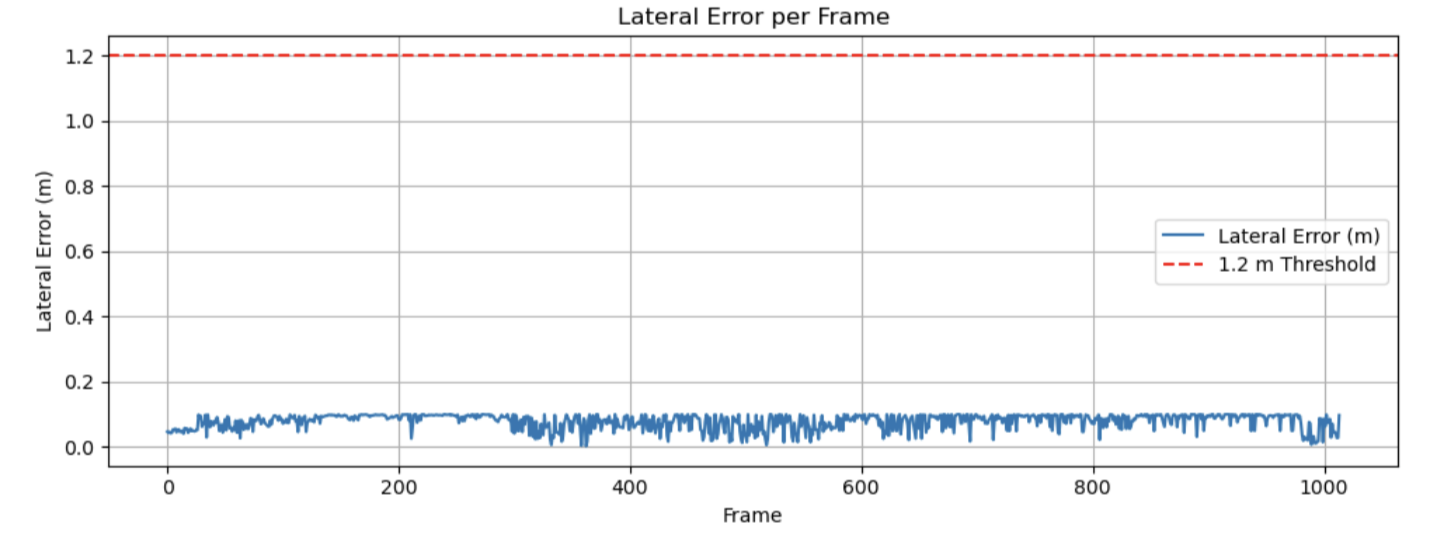| 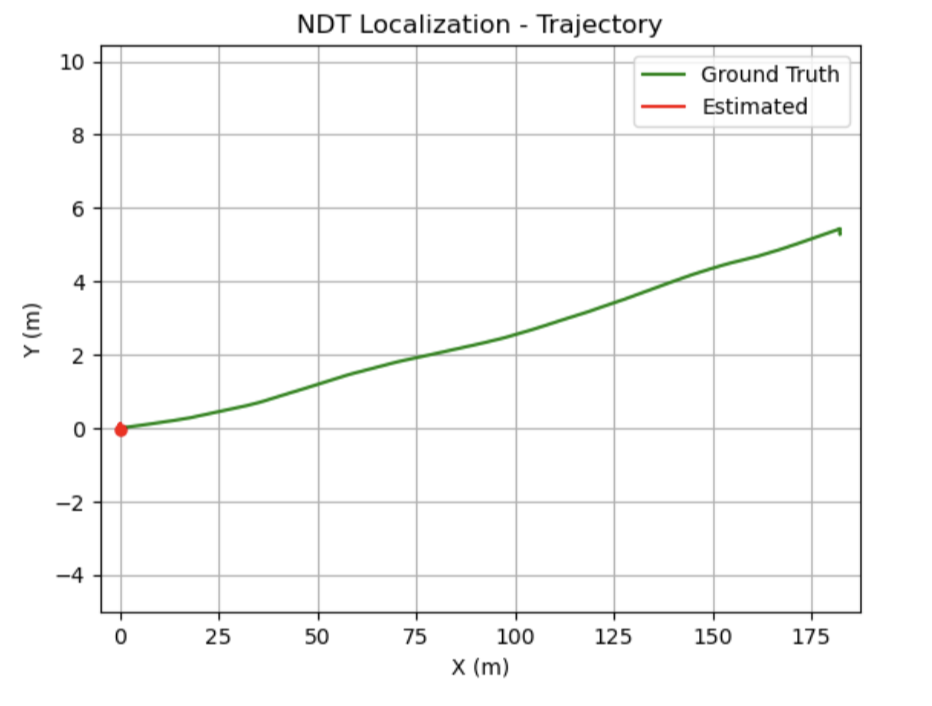

## Analysis 


### Complexity of ICP
The time complexity of our current ICP algorithm can be analyzed as follows:
1. Finding Correspondences: For each point in the source cloud (P current), we find the closest point in the target cloud (Q). This requires calculating the Euclidean distance between each point in P. current and all points in Q, which is an O(N * M) operation, where N is the number of points in P. current and M is the number of points in Q.
2. Singular Value Decomposition (SVD): The SVD step, which is used to compute the rotation matrix, is an O(K^3) operation, where k is the dimensionality of the point cloud (typically 3 in 3D point clouds). Since K=3, this step is a constant-time operation with respect to
the number of points
3. Total Complexity:
• In total, the complexity of each iteration is dominated by the O(N * M) complexity of finding correspondences.
• Therefore, the overall time complexity is O(* N * M), where I is the number of iterations in the ICP process.

ICP Summary:
- Average Lateral Error: 0.45 m
- Maximum Pose Error: 1.10 m
- Frames above 1.2m error: 0 

NDT Summary:
- Average Lateral Error: 0.078 m
- Max Lateral Error: 0.100 m
- Mean Computation Time per Frame: 2.749 s

### Algorithm Comparison

| **Comparison Metrics**    | **ICP** | **NDT** |
|---------------------------|---------|---------|
| **Localization Error**     | High accuracy but not as high as NDT, with a high error almost touching the threshold (1.1 m). Average of 0.45 m 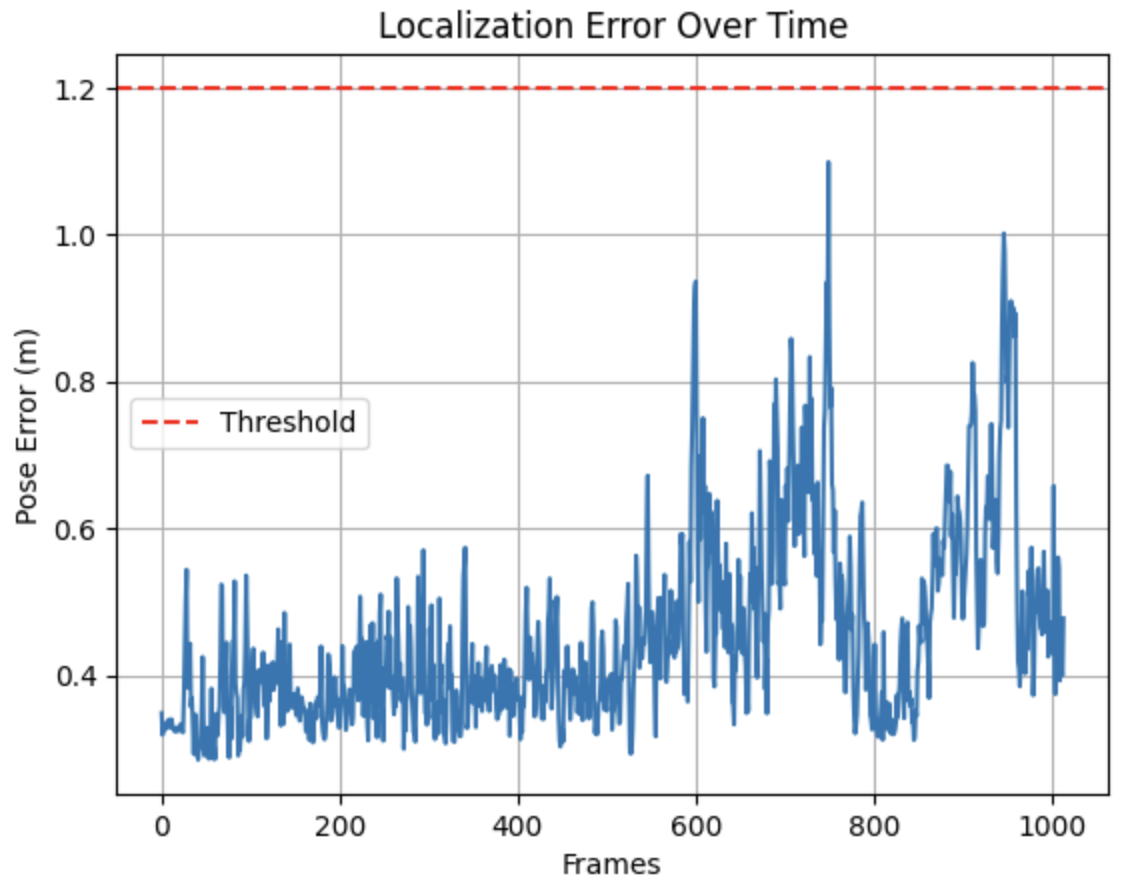 | High localization accuracy, with a mean lateral error under 8 centimeters, and a worst-case lateral error just reaching 10 centimeters. This level of precision is suitable for applications requiring fine-grained pose estimation. 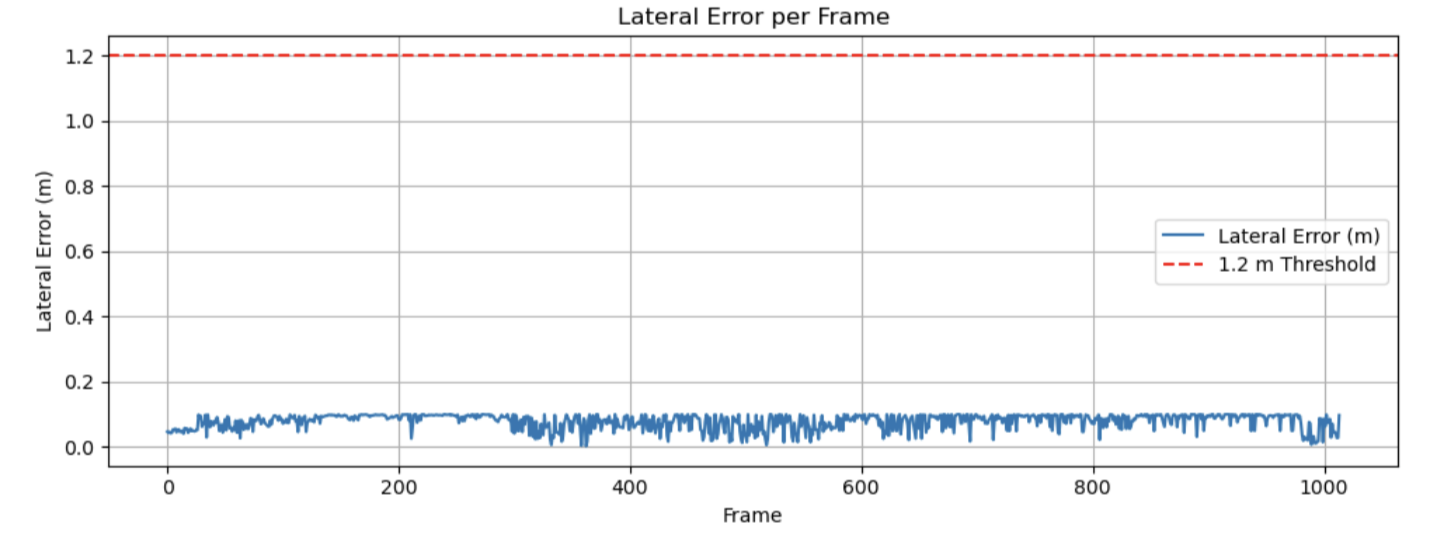 |
| **Computation Time**       | It's mostly consistent around 0.6s seconds, with occasional spikes — notably one at 1.11 seconds. | While the algorithm performs well in terms of accuracy, it comes at the cost of higher computational load, with a mean processing time of 2.749 seconds per frame. This is significantly slower than real-time (e.g., 10–30 FPS) requirements and suggests the current configuration is better suited for offline processing or slow-rate pose correction modules. |
| **Complexity**             | Each iteration has a time complexity of O(N × M), where N and M are the number of points in the source and target clouds, respectively. This is mainly due to the brute-force nearest-neighbor search. The SVD step is negligible (O(1)). Memory usage grows with iterations and correspondence count. | NDT uses a probabilistic model where the target point cloud is converted into a voxel grid of normal distributions, reducing the need for exhaustive point-to-point comparisons. This grid-based representation speeds up alignment and reduces complexity from O(N × M) to a more manageable level depending on voxel size and resolution. However, the voxelization step and the use of iterative optimization (e.g., Newton's method) introduce their own computational overhead, contributing to the higher per-frame time. |
| **Memory Usage**          | The algorithm stores the transformations (R list, t_list) and correspondences (corres list) for each iteration. The memory usage will grow with the number of iterations and correspondences. However, this is relatively manageable unless the point clouds are extremely large. | Both the downsampled scan and the map are stored in memory. After downsampling (e.g., VoxelGrid filter), their size is reduced, but still contributes. Typical memory cost: N * sizeof(PointXYZ) One point ≈ 3 floats = 12 bytes E.g., 100,000 points ≈ 1.2 MB per cloud |

## Conclusion
NDT is recommended for high-precision applications where computational time is less critical and ICP is better suited for time-sensitive applications where speed is prioritized over accuracy.